In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
import pandas as pd
import numpy as np

# Load the file from your /data folder
# Ensure you renamed the file or updated the path below
file_path = './data/0.7inner-100watt-67V2Iv.csv'
df = pd.read_csv(file_path)

# Clean column names (removes the leading spaces)
df.columns = df.columns.str.strip()

print(f"Loaded {len(df)} rows of data.")
print("Columns found:", df.columns.tolist())

Loaded 143348 rows of data.
Columns found: ['Time Stamp', 'X-axis', 'Y-axis', 'Z-axis']


In [3]:
def create_triaxial_windows(dataframe, window_size=1000):
    X_data = []
    # We use all three axes for a stronger "Fingerprint"
    features = dataframe[['X-axis', 'Y-axis', 'Z-axis']].values
    
    for i in range(0, len(features) - window_size, window_size):
        window = features[i : i + window_size]
        # Normalization (Crucial for Deep Learning)
        window = (window - np.mean(window)) / np.std(window)
        X_data.append(window)
        
    return np.array(X_data)

# Create windows of 1000 samples each
X_windows = create_triaxial_windows(df)

# Create 'Synthetic Temperature' for 100W load (e.g., ~45 degrees Celsius)
# In a real project, this would come from your LM35 sensor
T_temp = np.full((len(X_windows), 1), 45.0) 

# Create labels (Target): Since this is the 100W file, the target is 100
Y_load = np.full((len(X_windows), 1), 100.0)

print(f"Created {X_windows.shape[0]} windows.")
print(f"Each window shape: {X_windows.shape[1:]} (Samples, Axes)")

Created 143 windows.
Each window shape: (1000, 3) (Samples, Axes)


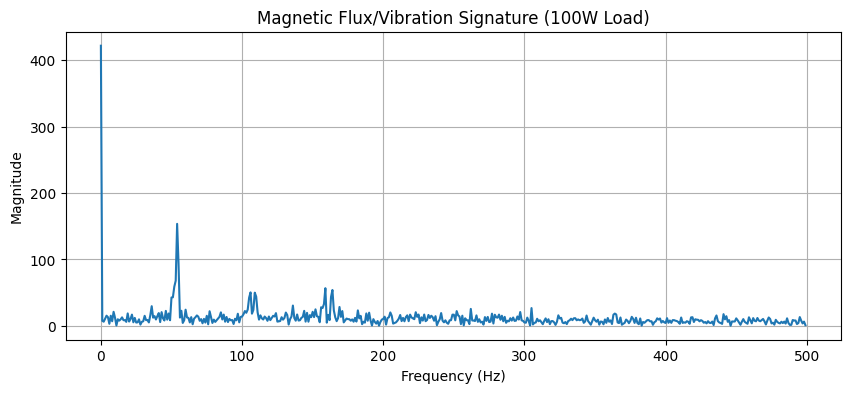

In [4]:
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

# Take one window of the X-axis
sample_signal = X_windows[0, :, 0] 
n = len(sample_signal)
yf = fft(sample_signal)
xf = fftfreq(n, 1/1000) # Assuming 1kHz sampling for visualization

plt.figure(figsize=(10, 4))
plt.plot(xf[:n//2], np.abs(yf[:n//2]))
plt.title("Magnetic Flux/Vibration Signature (100W Load)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.show()

In [5]:
# 1. Update the Model for Triaxial Input (1000 samples, 3 axes)
def build_final_triaxial_model():
    # Branch 1: Triaxial Magnetic/Vibration Signal
    # Input shape is (1000, 3) because we have X, Y, and Z axes
    flux_in = layers.Input(shape=(1000, 3), name="Triaxial_Flux")
    x = layers.Conv1D(64, 3, activation='relu')(flux_in)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, activation='relu')(x)
    x = layers.GlobalAveragePooling1D()(x)

    # Branch 2: Temperature Input
    temp_in = layers.Input(shape=(1,), name="Temperature_Input")
    y = layers.Dense(16, activation='relu')(temp_in)

    # Merging the two signatures
    merged = layers.concatenate([x, y])
    z = layers.Dense(64, activation='relu')(merged)
    # Output: Single number representing Load (e.g., 100 for 100W)
    output = layers.Dense(1, activation='linear')(z)

    model = models.Model(inputs=[flux_in, temp_in], outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# 2. Build and Train
tri_model = build_final_triaxial_model()
print("Deep Net Architecture for (1000, 3) + Temp is Ready.")

# 3. Training (Using the variables from your previous cells)
# We use validation_split to see how the model learns on "unseen" data
history = tri_model.fit(
    x=[X_windows, T_temp], 
    y=Y_load, 
    epochs=15, 
    batch_size=16, 
    validation_split=0.2
)

# 4. Make a Test Prediction
sample_flux = X_windows[0:1] # Take the first window
sample_temp = T_temp[0:1]    # Take the first temperature
prediction = tri_model.predict([sample_flux, sample_temp])

print(f"\n--- Prediction Test ---")
print(f"Actual Load: {Y_load[0][0]}W")
print(f"AI Predicted Load: {prediction[0][0]:.2f}W")

Deep Net Architecture for (1000, 3) + Temp is Ready.
Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 8821.8145 - mae: 93.8990 - val_loss: 7819.8696 - val_mae: 88.4300
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 7199.8652 - mae: 84.8156 - val_loss: 6155.0396 - val_mae: 78.4541
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 5487.5703 - mae: 74.0178 - val_loss: 4421.3516 - val_mae: 66.4932
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 3692.5554 - mae: 60.6254 - val_loss: 2437.0796 - val_mae: 49.3668
Epoch 5/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 1658.5410 - mae: 40.2183 - val_loss: 548.4579 - val_mae: 23.4190
Epoch 6/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 198.5045 - mae: 11.7305 - val_loss: 46.4106 - val_mae: 6.8105
Epoch 7/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 162.5306 - mae: 12.3709 - val_loss: 201.0091 - val_mae: 14.1766
Epoch 8/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 99.0128 - mae: 9.4111 - val_loss: 2.